In [1]:
from scripts import indices, plot, validate
import config

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from pathlib import Path

Set up of input data: random samples of surface reflectance across all 8 PS bands, labeled by land cover class (generated via QGIS model)

In [2]:
fp_bands = Path(r'C:\\Users\\remot\\Documents\\Jerome\\03_Independent_Research\\20260630 Mangrove and Seagrass Monitoring\\03_Data_management\\02_Processed_data\\Shapefiles\\Hinatuan-SurigaoDelSur_PS8BandsSamples-Corrected_LandCoverNAMRIA_20210729.csv')

df_bands = pd.read_csv(fp_bands).drop(columns=['id', 'xcoord', 'ycoord', 'gmw1'])
# df_bands['LCM_CLASS'] = df_bands['LCM_CLASS'].astype('category')

band_names = [col for col in df_bands.columns if col.startswith('b')]
df_bands = indices.remove_outliers(df_bands, band_names, impute=True)

df_bands.head()

Number of outliers detected:  869


,LCM_CLASS,b1,b2,b3,b4,b5,b6,b7,b8
0,Annual Crop,155,321,504,525,553,465,1060,2996
1,Annual Crop,74,261,510,560,443,288,1120,4128
2,Annual Crop,127,295,536,597,561,437,1105,3452
3,Annual Crop,76,238,451,464,458,357,811,2773
4,Annual Crop,195,322,560,623,632,493,1150,4329


In [5]:
df_bands_melt = df_bands.melt(
    id_vars=['LCM_CLASS'],
    value_vars=band_names,
    var_name='band',
    value_name='sr'
)

df_bands_melt.head()

,LCM_CLASS,band,sr
0,Annual Crop,b1,155
1,Annual Crop,b1,74
2,Annual Crop,b1,127
3,Annual Crop,b1,76
4,Annual Crop,b1,195


Initial exploration: are mangroves spectrally separable from other dense terrestrial vegetation (e.g., perennial cropland, which dominates in the current AOI)

In [6]:
df_bands_melt['LCM_CLASS'].unique()

<ArrowStringArray>
[    'Annual Crop',    'Brush/Shrubs',        'Built-up', 'Mangrove Forest',
        'Fishpond',       'Grassland',    'Inland Water',     'Open Forest',
  'Perennial Crop']
Length: 9, dtype: str

In [7]:
vegetation_classes = [
    'Mangrove Forest', 
    'Perennial Crop', 
    # 'Annual Crop', 
    # 'Brush/Shrubs'
]

First check: spectral signature chart 

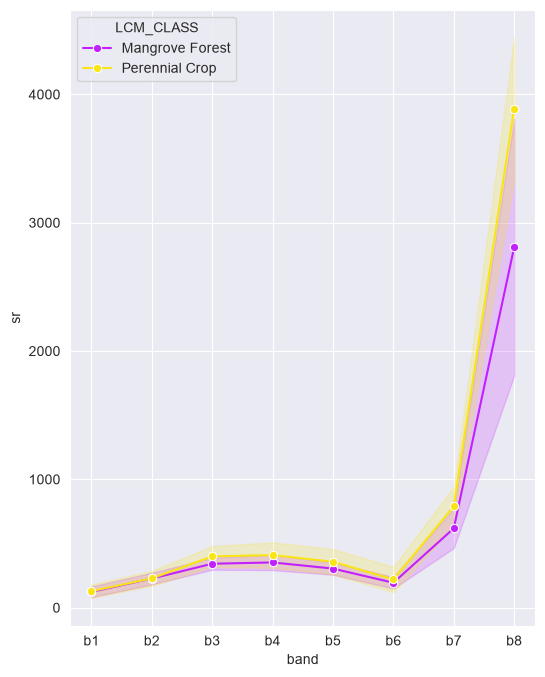

In [8]:
sns.set_style('darkgrid')
ax = plot.spectral_signature(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    value_column='sr',
    band_column='band',
    cats_compared=vegetation_classes
)

ax.figure.set_size_inches(6, 8)

Looking closer: boxplots to see if any band shows little overlap (i.e., good separability) between mangrove & perennial crop

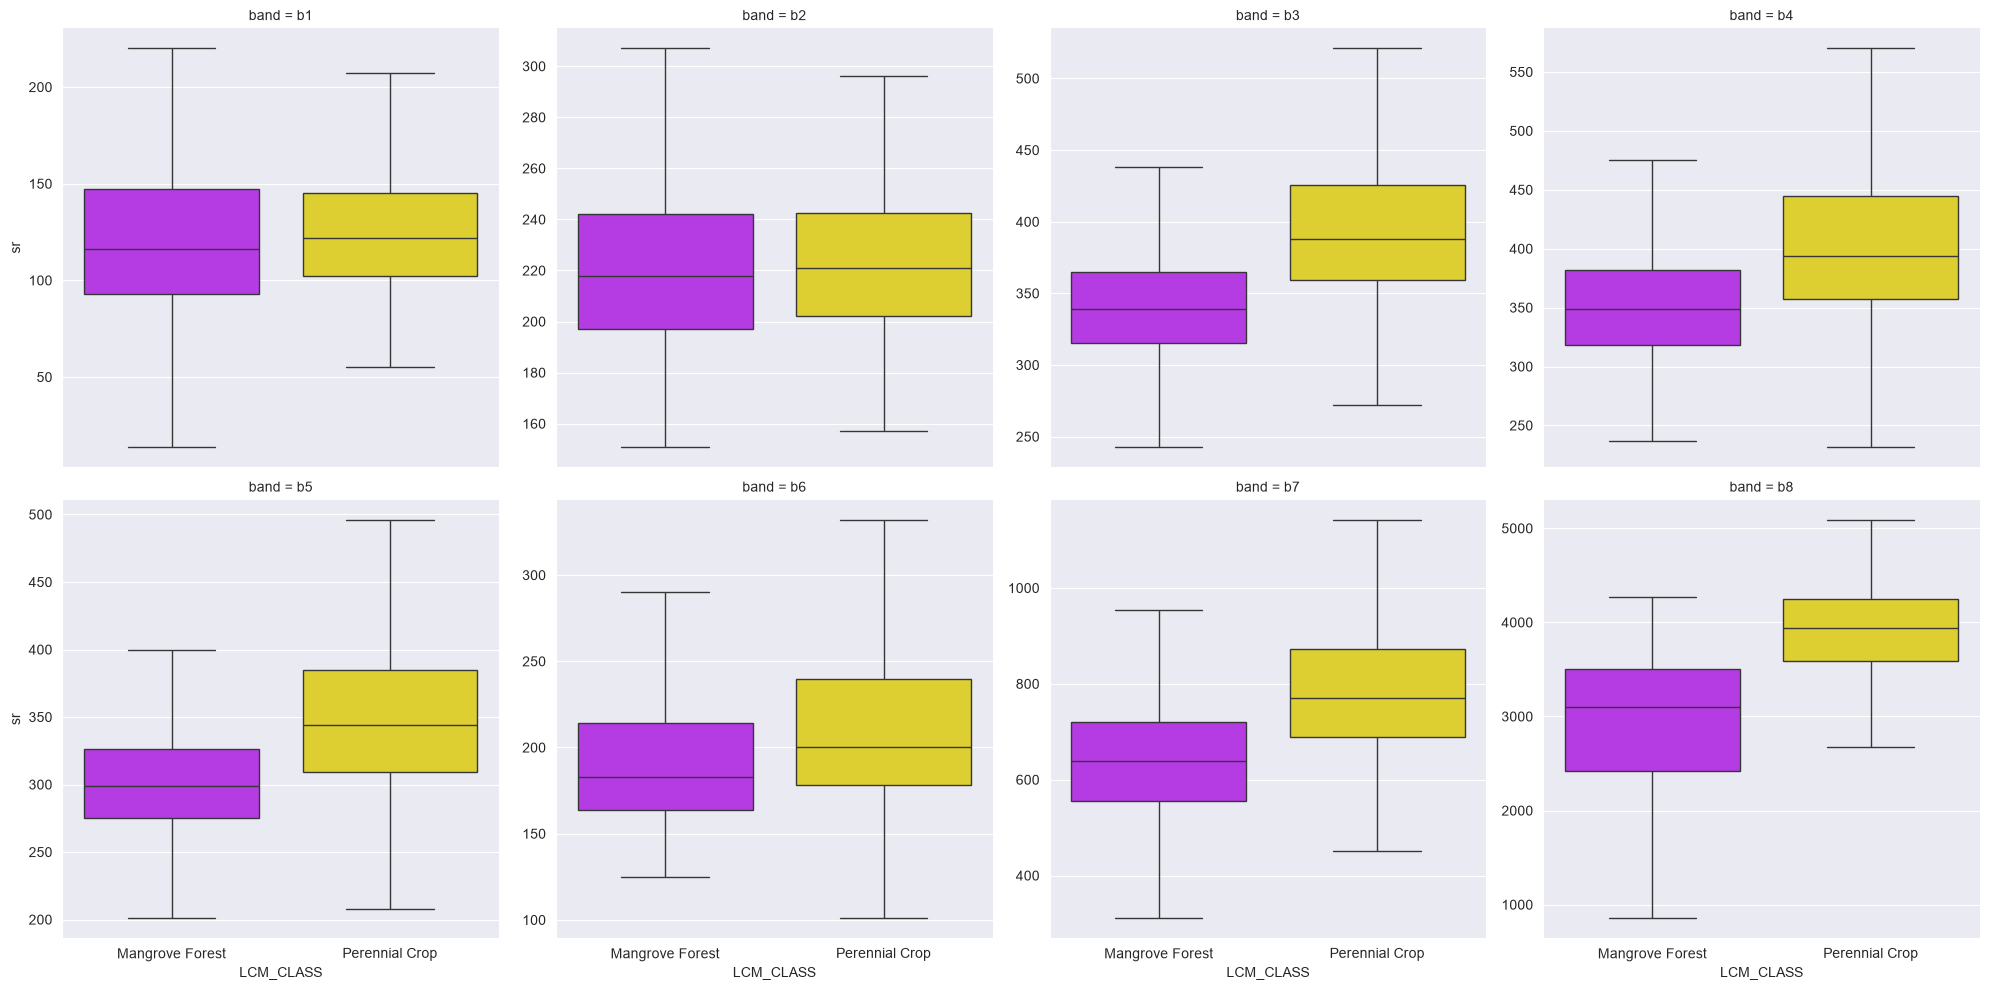

In [9]:
plot.boxplot_bands(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    value_column='sr',
    band_column='band',
    cats_compared=vegetation_classes,
    col_wrap=4
)

Could the two classes be more separable if viewed from two dimensions?

<Axes: xlabel='b8', ylabel='b7'>

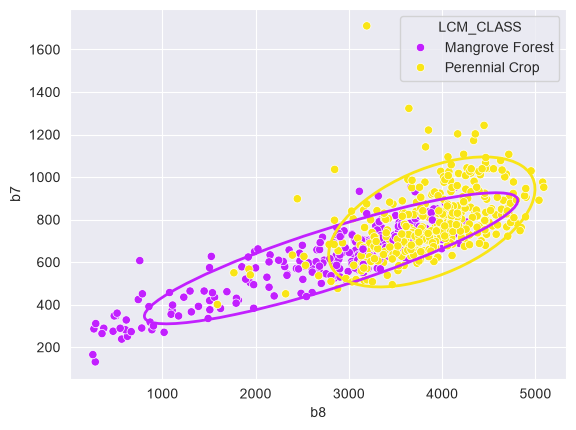

In [10]:
plot.scatterplot_bands(
    data=df_bands,
    band_x='b8',
    band_y='b7',
    category_column='LCM_CLASS',
    n_std=2,
    cats_compared=vegetation_classes
)

Beyond simple visual assessments, let's quantitatively measure their separability: first, by taking the per-band means and standard deviation for the two classes

In [11]:
df_stats = validate.agg_per_class(
    data=df_bands,
    category_column='LCM_CLASS',
    band_names=band_names,
    cats_compared=vegetation_classes,
)

df_stats.head()

,LCM_CLASS,b1_mean,b1_std,b2_mean,b2_std,b3_mean,b3_std,b4_mean,b4_std,b5_mean,b5_std,b6_mean,b6_std,b7_mean,b7_std,b8_mean,b8_std
0,Mangrove Forest,123.018657,42.059478,226.776119,45.18429,342.164179,46.947607,352.160448,59.835546,304.212687,47.880191,193.973881,45.035101,618.033582,154.081727,2808.929104,1000.820962
1,Perennial Crop,128.517520,50.807497,227.900270,58.51166,399.113208,80.330117,409.137466,99.104913,357.369272,99.365996,219.552561,98.824766,789.000000,152.866432,3888.865229,553.052276


In [12]:
df_separability = validate.get_separability(
    df_stats=df_stats,
    category_column='LCM_CLASS',
    category_a='Mangrove Forest',
    category_b='Perennial Crop',
    band_names=band_names
)

df_separability.head()

,band,m_statistic,jm_distance
0,b1,0.059212,0.145295
1,b2,0.010841,0.181334
2,b3,0.447439,0.547783
3,b4,0.358480,0.478676
4,b5,0.361005,0.575350


Jeffries-Matusita distance for mangrove vs. perennial crop for each band. Horizontal line (=1.88) is the threshold for sufficient separability.

<Axes: xlabel='band', ylabel='jm_distance'>

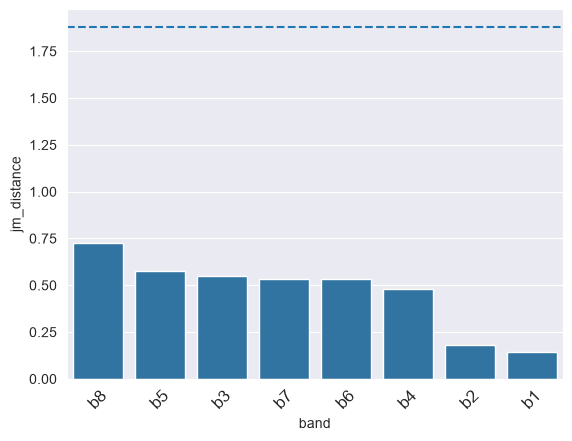

In [13]:
plot.separability_2class(
    data_separability=df_separability,
    separability_column='jm_distance',
    band_column='band',
    threshold=1.88
)

Looks like the two classes are not separable based on specific bands. Next, let's try out VNIR-only mangrove-specific indices described in existing literature.

Let's first calculate NDVI and NDWI, which are NOT mangrove-specific indices but are used as building blocks for ones later on.

In [14]:
ndvi = indices.normalized_difference_2band(
    band_a=df_bands.b8,
    band_b=df_bands.b6
)

ndwi = indices.normalized_difference_2band(
    band_a=df_bands.b4,
    band_b=df_bands.b8
)

Next, let's proceed to the mangrove-specific indices.

In [15]:
cmri = ndvi - ndwi

mmri = indices.normalized_difference_2band(
    band_a=np.abs(ndwi),
    band_b=np.abs(ndvi)
)

mvdi = (
    ((df_bands.b7 - df_bands.b6) * (df_bands.b8 + df_bands.b6))
    / ((df_bands.b8 - df_bands.b7) * (df_bands.b8 - df_bands.b6))
)

Let's compile everything into one DataFrame.

In [24]:
df_indices = df_bands.copy(deep=True).drop(columns=band_names)
index_names = ['ndvi', 'ndwi', 'cmri', 'mmri', 'mvdi']
df_indices[index_names] = np.array([ndvi, ndwi, cmri, mmri, mvdi]).T
df_indices = indices.remove_outliers(df_indices, index_names, impute=True)
df_indices.head()

Number of outliers detected:  869


,LCM_CLASS,ndvi,ndwi,cmri,mmri,mvdi
0,Annual Crop,0.731292,-0.701789,1.433081,-0.020587,0.420263
1,Annual Crop,0.869565,-0.761092,1.630657,-0.066521,0.318085
2,Annual Crop,0.775264,-0.705112,1.480376,-0.047387,0.367125
3,Annual Crop,0.771885,-0.713315,1.485200,-0.039436,0.299781
4,Annual Crop,0.795521,-0.748384,1.543905,-0.030530,0.259791


In [25]:
df_indices_melt = df_indices.melt(
    id_vars=['LCM_CLASS'],
    value_vars=index_names,
    value_name='value',
    var_name='index'
)

df_indices_melt.head()

,LCM_CLASS,index,value
0,Annual Crop,ndvi,0.731292
1,Annual Crop,ndvi,0.869565
2,Annual Crop,ndvi,0.775264
3,Annual Crop,ndvi,0.771885
4,Annual Crop,ndvi,0.795521


Now that we have the index values, let's visually assess via boxplots:

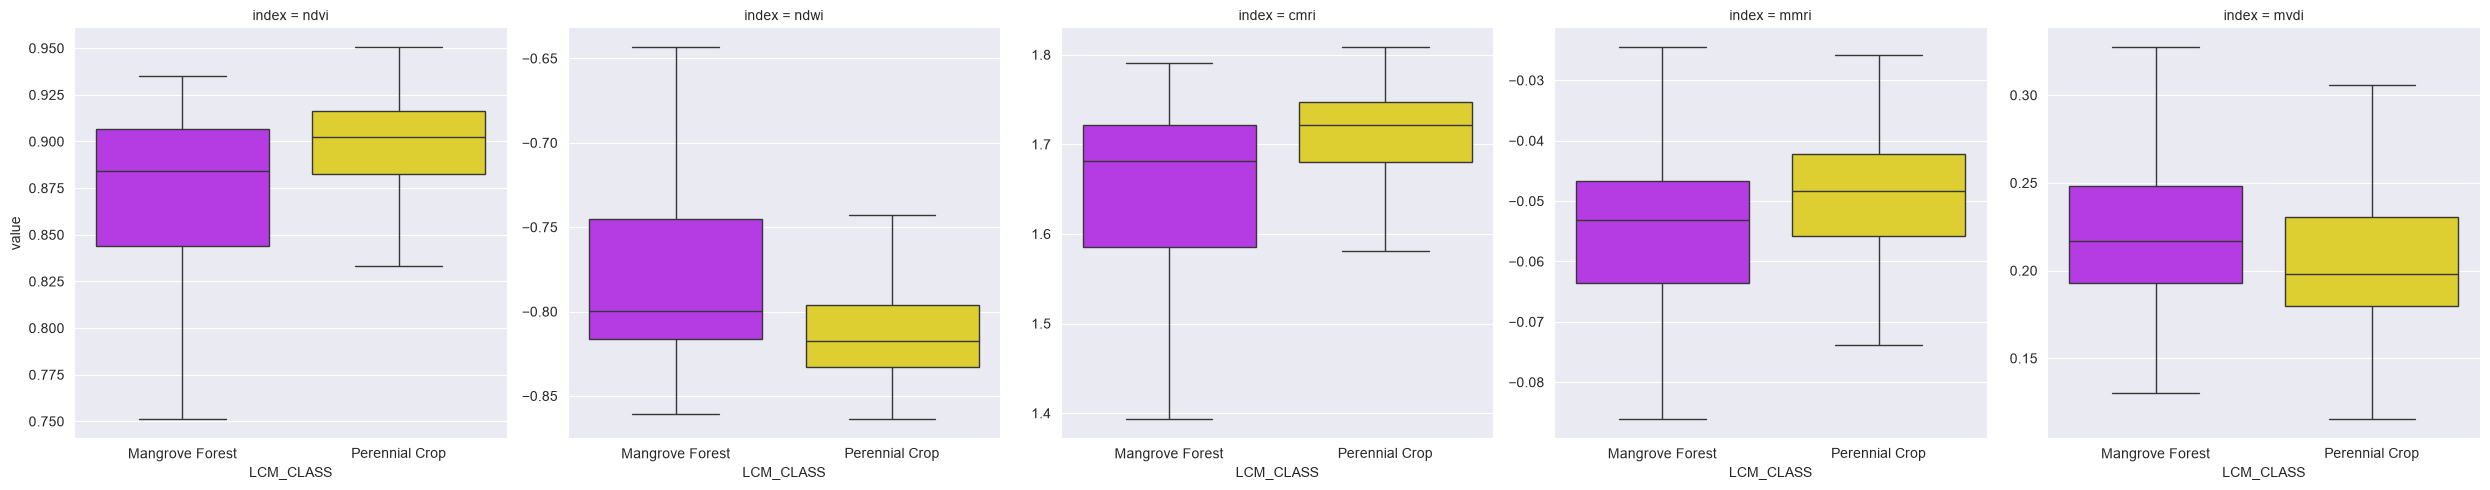

In [26]:
plot.boxplot_bands(
    data=df_indices_melt,
    category_column='LCM_CLASS',
    value_column='value',
    band_column='index',
    cats_compared=vegetation_classes
)

...and also two-dimensionally via scatterplot:

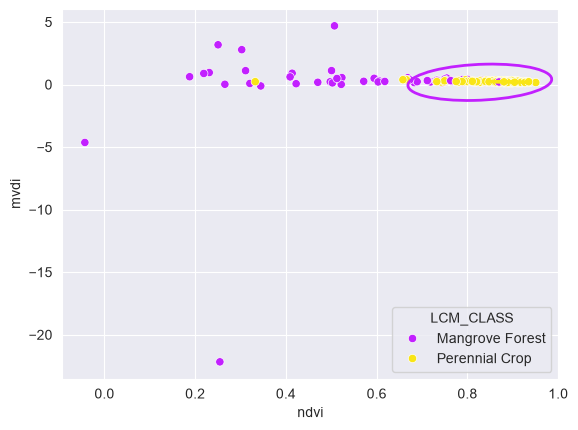

In [32]:
ax = plot.scatterplot_bands(
    data=df_indices,
    band_x='ndvi',
    band_y='mvdi',
    category_column='LCM_CLASS',
    cats_compared=vegetation_classes,
    n_std=1
)

# ax.set_ylim(-2,2)

In [28]:
# sns.displot(
#     data=df_indices_melt[df_indices_melt['LCM_CLASS'].isin(vegetation_classes)],
#     x='value',
#     col='index',
#     kind='hist',
#     hue='LCM_CLASS',
#     palette=config.PALETTE_LAND_COVER,
#     common_bins=False,
#     common_norm=False,
#     facet_kws=dict(sharex=False)
# )

Not looking great. Let's confirm our suspicions by calculating and plotting the separability metrics.

In [33]:
df_indices_stats = validate.agg_per_class(
    data=df_indices,
    category_column='LCM_CLASS',
    band_names=index_names,
    cats_compared=vegetation_classes
)

df_indices_stats

,LCM_CLASS,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,cmri_mean,cmri_std,mmri_mean,mmri_std,mvdi_mean,mvdi_std
0,Mangrove Forest,0.827264,0.158453,-0.729886,0.177495,1.557150,0.333962,-0.072327,0.106782,0.177805,1.453765
1,Perennial Crop,0.890959,0.049551,-0.807889,0.045211,1.698848,0.092834,-0.048863,0.012071,0.208361,0.044341


In [34]:
df_indices_separ = validate.get_separability(
    df_stats=df_indices_stats,
    category_column='LCM_CLASS',
    category_a='Mangrove Forest',
    category_b='Perennial Crop',
    band_names=index_names
).rename(columns={'band': 'index'})

df_indices_separ

,index,m_statistic,jm_distance
0,ndvi,0.306220,0.738205
1,ndwi,0.350251,0.823409
2,cmri,0.332004,0.788680
3,mmri,0.197426,1.032586
4,mvdi,0.020396,1.227320


Looks like none of them reach the threshold for good separability, but MVDI and MMRI perform better than the rest.

<Axes: xlabel='index', ylabel='jm_distance'>

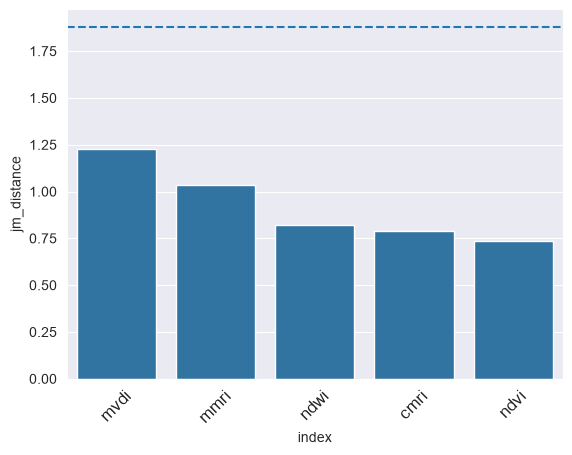

In [35]:
plot.separability_2class(
    data_separability=df_indices_separ,
    separability_column='jm_distance',
    band_column='index',
    threshold=1.88
)